EDA



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns   
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

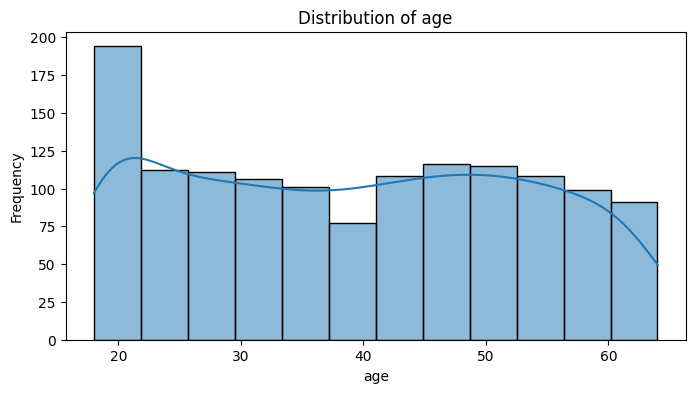

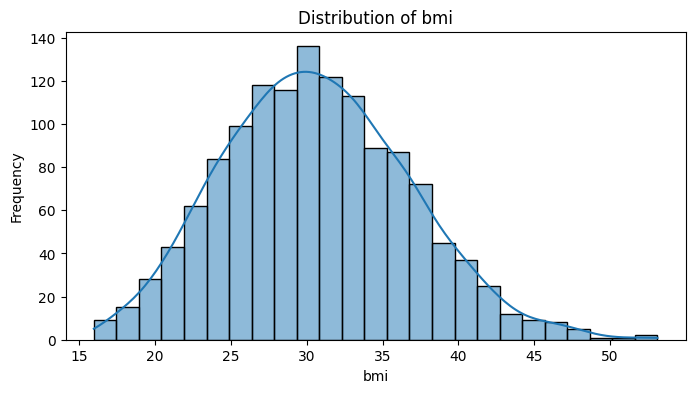

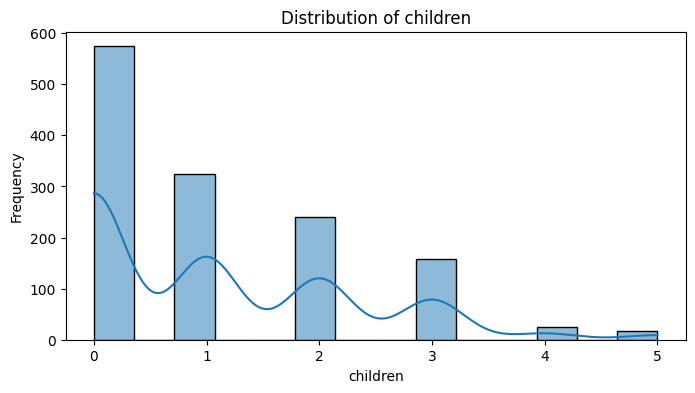

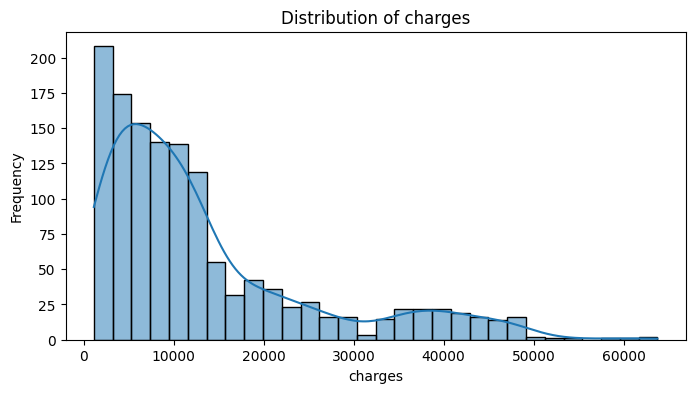

In [8]:

numeric_cols = ["age", "bmi", "children", "charges" ]
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    

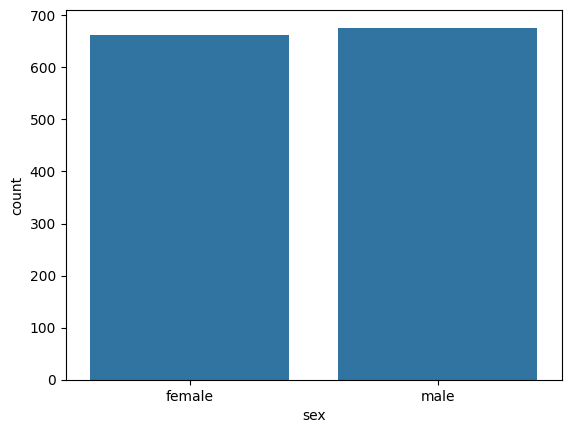

In [9]:
sns.countplot(x=df["sex"]) 
plt.show()

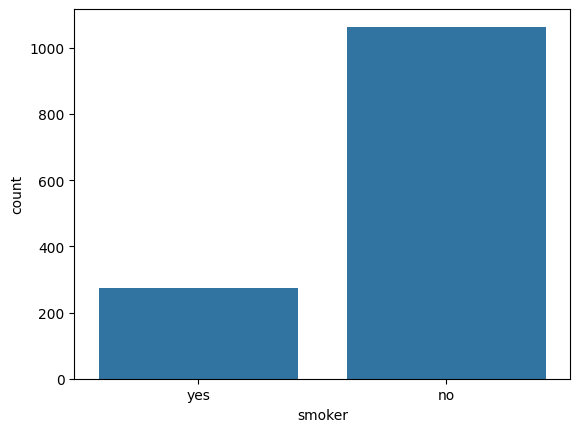

In [10]:
sns.countplot(x=df['smoker'])
plt.show()

<Axes: xlabel='region', ylabel='count'>

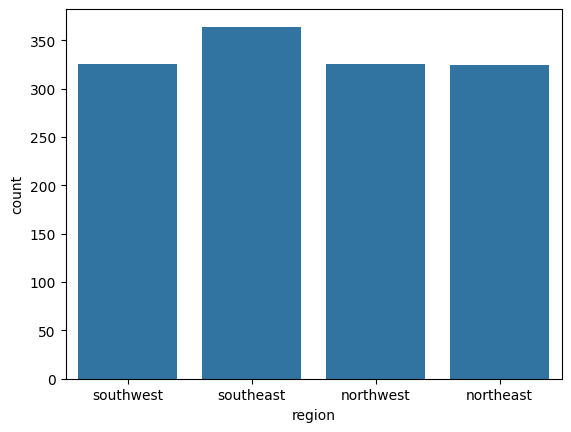

In [11]:
sns.countplot(x=df["region"])

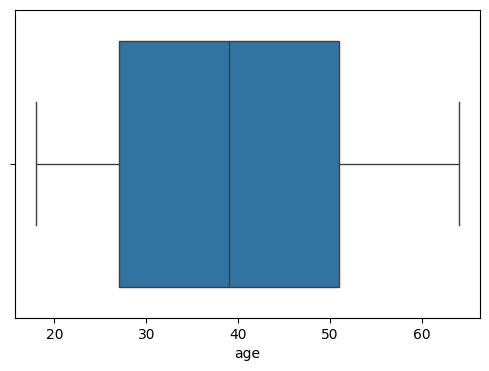

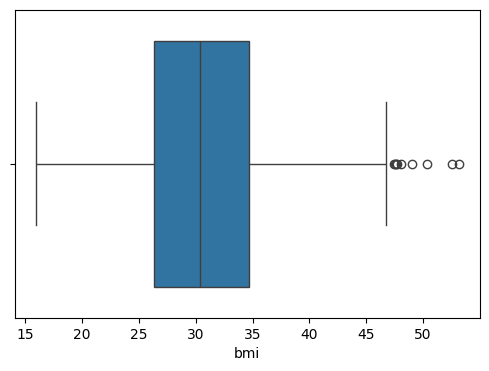

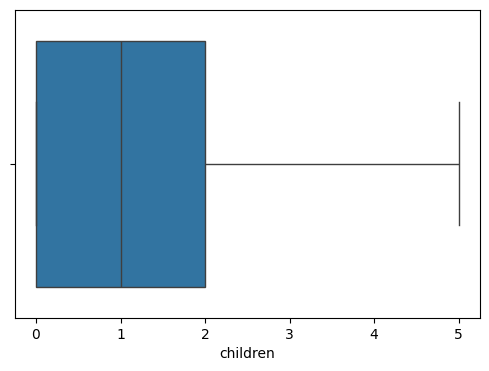

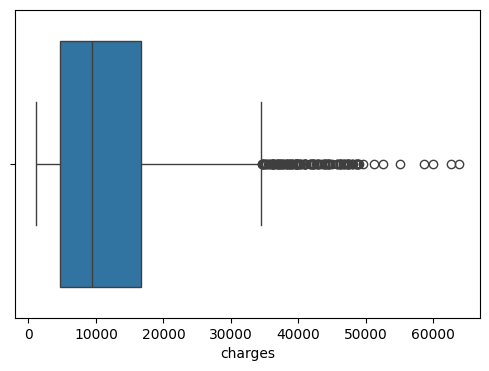

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.show()
    

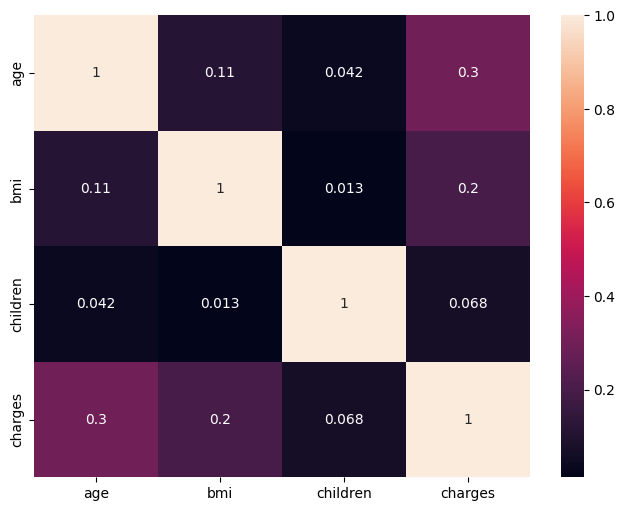

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


Data Cleaning and perprocessing

In [14]:
df_cleaned = df.copy()
 

In [15]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


there is no null value 


In [16]:
df_cleaned.shape

(1338, 7)

In [17]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [18]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

To get back my file data 

In [20]:
df_cleaned['sex'] = df['sex']

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
df_cleaned["sex"].value_counts()


sex
male      675
female    662
Name: count, dtype: int64

Labelled encoding 


In [23]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})



In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [26]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no':0,'yes':1})   

In [27]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


Rename the cells acc to their work 

In [28]:
df_cleaned.rename(columns ={
    "sex":"is_female",
    "smoker":"is_smoker"    
}, inplace=True)
df_cleaned.head()


,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [29]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

We apply here one hot encoding 

In [30]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["region"], drop_first=True )
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [31]:
df_cleaned = df_cleaned.astype(int)

In [32]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# Feature Engineering and Extraction 

<Axes: xlabel='bmi', ylabel='Count'>

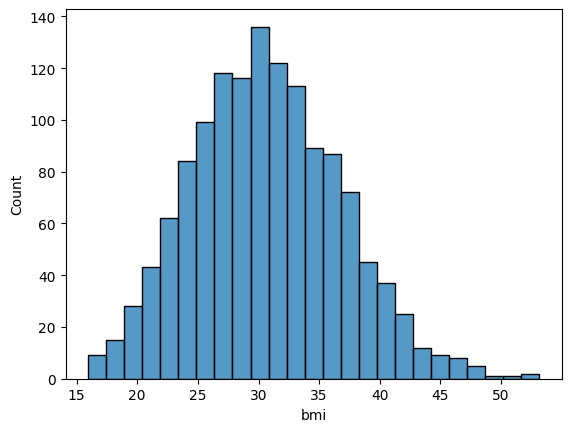

In [33]:
sns.histplot(df["bmi"])

In [34]:
df_cleaned["bmi_category"] = pd.cut(
    df_cleaned["bmi"],
    bins=[0, 18.5, 24.9, 29.9, np.inf],
    labels=["Underweight", "Normal weight", "Overweight", "Obese"]
)

In [35]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal weight
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [36]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["bmi_category"], drop_first=True)

In [37]:
df_cleaned.astype(int)  

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


Feature scaling 

In [38]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [39]:
from sklearn.preprocessing import StandardScaler      
cols =  ["age", "bmi", "children"] 
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
df_cleaned.head() 


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,False,True,False


In [40]:
!pip install scipy




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from scipy.stats import pearsonr
selected_features =[
    "age","bmi",  "children","age","is_female","bmi","children","is_smoker","charges",
    "region_northwest","region_southeast","region_southwest",
    "bmi_category_Normal weight","bmi_category_Overweight","bmi_category_Obese"
]
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned["charges"])[0] for feature in selected_features
    for feature in selected_features
}
correlations_df = pd.DataFrame(list(correlations.items()), columns=["feature", "Pearson Correlation with Charges"])
correlations_df.sort_values(by="Pearson Correlation with Charges", ascending=False)

,feature,Pearson Correlation with Charges
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298309
11,bmi_category_Obese,0.200348
1,bmi,0.196236
7,region_southeast,0.073577
2,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
3,is_female,-0.058046


In [42]:
cat_features = ["is_female", "is_smoker", 
                "region_northwest", "region_southeast", 
                "region_southwest",
                "bmi_category_Normal weight", 
                "bmi_category_Overweight", "bmi_category_Obese"]


In [46]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}
for feature in cat_features:
    contingency = pd.crosstab(df_cleaned[feature], df_cleaned['charges_bin'])
    chi2_stats, p_val, _, _ = chi2_contingency(contingency)
    decision = "Reject Null (keep feature)" if p_val < alpha else "Accept Null (drop feature)"
    chi2_results[col] = {
        "Chi2 Statistic": chi2_stats,
        "P-value": p_val,
        "Decision": decision
    }
    
    chi2_df = pd.DataFrame(chi2_results).T
    chi2_df = chi2_df.sort_values(by="P-value")
    print(chi2_df)  


        Chi2 Statistic  P-value                    Decision
charges      10.258784  0.01649  Reject Null (keep feature)
        Chi2 Statistic P-value                    Decision
charges     848.219178     0.0  Reject Null (keep feature)
        Chi2 Statistic   P-value                    Decision
charges        1.13424  0.768815  Accept Null (drop feature)
        Chi2 Statistic   P-value                    Decision
charges      15.998167  0.001135  Reject Null (keep feature)
        Chi2 Statistic   P-value                    Decision
charges       5.091893  0.165191  Accept Null (drop feature)
        Chi2 Statistic  P-value                    Decision
charges       3.708088  0.29476  Accept Null (drop feature)
        Chi2 Statistic   P-value                    Decision
charges        4.25149  0.235557  Accept Null (drop feature)
        Chi2 Statistic   P-value                    Decision
charges       8.515711  0.036473  Reject Null (keep feature)


In [48]:
final_df = df_cleaned[["age", "bmi", "children", "is_female", "is_smoker", "region_southeast","bmi_category_Obese", "charges"]]
final_df

,age,bmi,children,is_female,is_smoker,region_southeast,bmi_category_Obese,charges
0,-1.440418,-0.517949,-0.909234,1,1,0,False,16884
1,-1.511647,0.462463,-0.079442,0,0,1,True,1725
2,-0.799350,0.462463,1.580143,0,0,1,True,4449
3,-0.443201,-1.334960,-0.909234,0,0,0,False,21984
4,-0.514431,-0.354547,-0.909234,0,0,0,False,3866
...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,0,True,10600
1334,-1.511647,0.135659,-0.909234,1,0,0,True,2205
1335,-1.511647,0.952670,-0.909234,1,0,1,True,1629
1336,-1.297958,-0.844753,-0.909234,1,0,0,False,2007
